In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [11]:
file_path = Path("../dataset/Online Retail.xlsx")

df = pd.read_excel(file_path)

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(5268)

In [17]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [18]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [32]:
# We need to verify how many invoices represent cancellations. :

df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [21]:
cancelled_invoices = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled_invoices.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [22]:
cancelled_invoices.shape

(9288, 9)

In [23]:
df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [24]:
# Investigate zero/negative prices  :

df[df["UnitPrice"] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [25]:
df[df["UnitPrice"] <= 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [26]:
# Investigate missing CustomerID  

df[df["CustomerID"].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,3.32


In [27]:
df.groupby(df["CustomerID"].isna())["Revenue"].sum()

CustomerID
False    8300065.814
True     1447682.120
Name: Revenue, dtype: float64

In [28]:
# Investigate missing Description: 

df[df["Description"].isna()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [29]:
df[df["Description"].isna()][
    ["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
622,536414,22139,56,0.0,NaN
1970,536545,21134,1,0.0,NaN
1971,536546,22145,1,0.0,NaN
1972,536547,37509,1,0.0,NaN
1987,536549,85226A,1,0.0,NaN
1988,536550,85044,1,0.0,NaN
2024,536552,20950,1,0.0,NaN
2025,536553,37461,3,0.0,NaN
2026,536554,84670,23,0.0,NaN
2406,536589,21777,-10,0.0,NaN


In [30]:
# Check duplicate records: 

df[df.duplicated(keep=False)].sort_values(
    by=["InvoiceNo", "StockCode"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,3.30
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65


In [31]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [33]:
# Negative quantity without a C invoice

negative_non_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

negative_non_cancelled.shape


(1336, 9)

In [34]:
negative_non_cancelled[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,0.0,NaN,United Kingdom


In [35]:
# What are the zero-price records?

zero_price = df[df["UnitPrice"] == 0]

zero_price.shape

(2515, 9)

In [36]:
zero_price[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [37]:
# Check the descriptions/categories of zero-price records

zero_price["Description"].value_counts(dropna=False).head(20)

Description
NaN                                1454
check                               159
?                                    47
damages                              45
damaged                              43
found                                25
sold as set on dotcom                20
adjustment                           16
Damaged                              14
Unsaleable, destroyed.                9
thrown away                           9
FRENCH BLUE METAL DOOR SIGN 1         9
FRENCH BLUE METAL DOOR SIGN 8         8
amazon                                8
Found                                 8
FRENCH BLUE METAL DOOR SIGN 4         7
Amazon                                7
FRENCH BLUE METAL DOOR SIGN 3         7
RECIPE BOX PANTRY YELLOW DESIGN       7
OWL DOORSTOP                          7
Name: count, dtype: int64

In [38]:
# exact duplicates after removing nothing

df_no_duplicates = df.drop_duplicates()

df_no_duplicates.shape

(536641, 9)

In [39]:
df_clean = df.copy()

In [40]:
df_clean = df_clean.drop_duplicates()

In [41]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [42]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [43]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [44]:
df_clean = df_clean.reset_index(drop=True)

In [45]:
df_clean.shape

(524878, 9)

In [46]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [47]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [48]:
(df_clean["Quantity"] <= 0).sum()

np.int64(0)

In [49]:
(df_clean["UnitPrice"] <= 0).sum()

np.int64(0)

In [50]:
df_clean.duplicated().sum()

np.int64(0)

In [51]:
df_clean["CustomerID"].isna().sum()

np.int64(132186)

In [52]:
df_clean["Description"].isna().sum()

np.int64(0)

In [53]:
cleaning_summary = {
    "Original Rows": len(df),
    "Cleaned Rows": len(df_clean),
    "Rows Removed": len(df) - len(df_clean),
    "Duplicate Rows Removed": df.duplicated().sum(),
    "Negative Quantity Removed": (df["Quantity"] < 0).sum(),
    "Non-Positive Price Removed": (df["UnitPrice"] <= 0).sum(),
    "Missing CustomerID After Cleaning": df_clean["CustomerID"].isna().sum()
}

cleaning_summary

{'Original Rows': 541909,
 'Cleaned Rows': 524878,
 'Rows Removed': 17031,
 'Duplicate Rows Removed': np.int64(5268),
 'Negative Quantity Removed': np.int64(10624),
 'Non-Positive Price Removed': np.int64(2517),
 'Missing CustomerID After Cleaning': np.int64(132186)}

In [54]:
retention_rate = (len(df_clean) / len(df)) * 100

print(f"Data Retention Rate: {retention_rate:.2f}%")

Data Retention Rate: 96.86%


In [55]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566


In [56]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [57]:
df_clean["Revenue"].sum()

np.float64(10642110.804000001)

In [58]:
print("Start Date:", df_clean["InvoiceDate"].min())
print("End Date:", df_clean["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [59]:
print("Number of Days:",
      (df_clean["InvoiceDate"].max() - df_clean["InvoiceDate"].min()).days)

Number of Days: 373


In [60]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [61]:
df_clean["Year_Month"] = (
    df_clean["InvoiceDate"].dt.to_period("M").astype(str)
)

In [62]:
df_clean[
    ["InvoiceDate", "Year", "Month", "Month_Name",
     "Day", "Day_Name", "Hour", "Year_Month"]
].head()

,InvoiceDate,Year,Month,Month_Name,Day,Day_Name,Hour,Year_Month
0,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
1,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
2,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
3,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
4,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12


In [63]:
df_clean["StockCode"].nunique()

3922

In [64]:
df_clean["InvoiceNo"].nunique()

19960

In [65]:
df_clean["CustomerID"].nunique()

4338

In [66]:
df_clean["Country"].nunique()

38

In [67]:
top_products_quantity = (
    df_clean.groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [68]:
top_products_revenue = (
    df_clean.groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [69]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [70]:
country_transactions = (
    df_clean.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

country_transactions

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [71]:
output_path = Path("../dataset/online_retail_clean.csv")

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ..\dataset\online_retail_clean.csv


In [72]:
cleaning_summary

{'Original Rows': 541909,
 'Cleaned Rows': 524878,
 'Rows Removed': 17031,
 'Duplicate Rows Removed': np.int64(5268),
 'Negative Quantity Removed': np.int64(10624),
 'Non-Positive Price Removed': np.int64(2517),
 'Missing CustomerID After Cleaning': np.int64(132186)}

In [73]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour
count,524878.000000,524878,524878.000000,392692.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399,2010.921904,7.552237,15.022472,13.073991
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000,2011.000000,5.000000,7.000000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000,2011.000000,8.000000,15.000000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000,2011.000000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,156.280031,NaN,36.093028,1713.539549,271.693566,0.268323,3.508164,8.660738,2.442994


In [74]:
print("Start Date:", df_clean["InvoiceDate"].min())
print("End Date:", df_clean["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [75]:
df_clean["Revenue"].sum()

np.float64(10642110.804000001)

In [76]:
df_clean["Week"] = df_clean["InvoiceDate"].dt.isocalendar().week

In [77]:
df_clean["Quarter"] = (
    "Q" + df_clean["InvoiceDate"].dt.quarter.astype(str)
)

In [78]:
df_clean["Day_of_Week"] = df_clean["InvoiceDate"].dt.dayofweek

In [79]:
df_clean["Revenue_Rounded"] = df_clean["Revenue"].round(2)

In [80]:
monthly_revenue = (
    df_clean.groupby("Year_Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

Year_Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Name: Revenue, dtype: float64

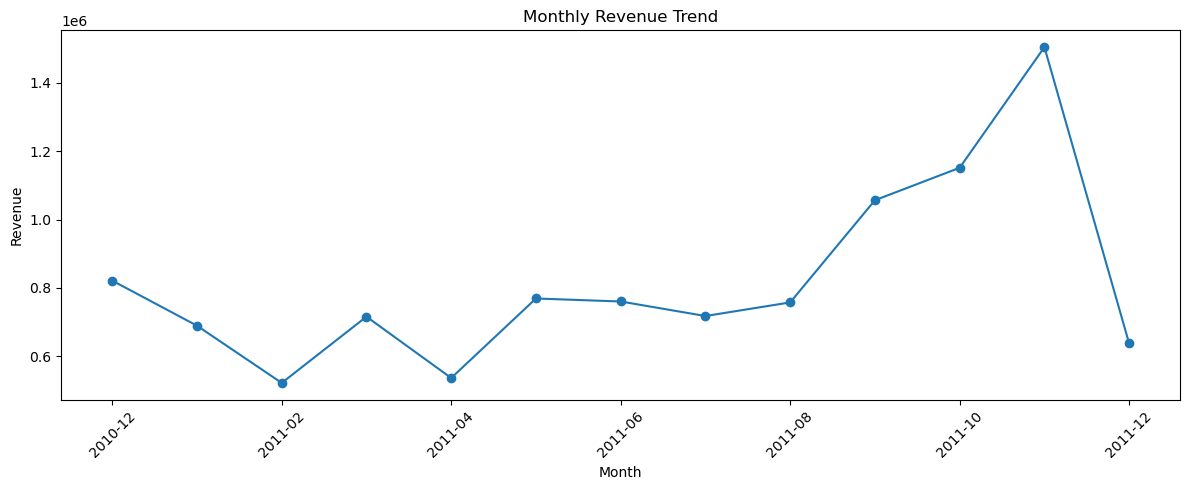

In [81]:
monthly_revenue.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
monthly_orders = (
    df_clean.groupby("Year_Month")["InvoiceNo"]
    .nunique()
    .sort_index()
)

monthly_orders

Year_Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Name: InvoiceNo, dtype: int64

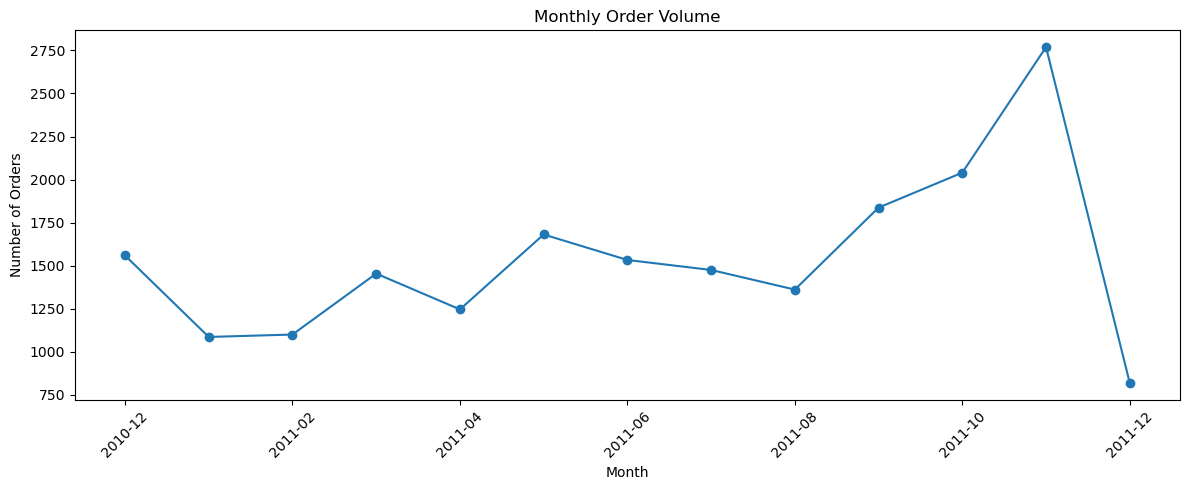

In [83]:
monthly_orders.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
# AOV = Revenue / Number of Unique Orders

total_revenue = df_clean["Revenue"].sum()
total_orders = df_clean["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: £{aov:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Average Order Value: £533.17


In [86]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

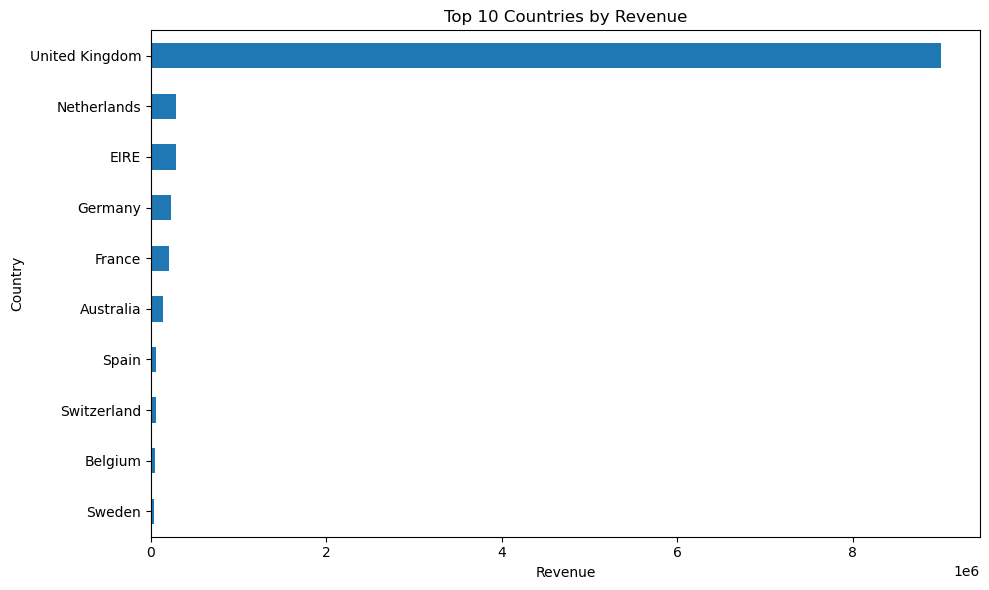

In [87]:
country_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [88]:
top_products_quantity = (
    df_clean.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [89]:
top_products_revenue = (
    df_clean.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [90]:
df_customer = df_clean.dropna(
    subset=["CustomerID"]
).copy()

In [91]:
customer_count = df_customer["CustomerID"].nunique()

print(f"Unique Customers: {customer_count:,}")

Unique Customers: 4,338


In [92]:
output_path = Path("../dataset/online_retail_clean.csv")

df_clean.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: ..\dataset\online_retail_clean.csv


In [93]:
import os

os.path.exists(output_path)

True